V-Plot Building


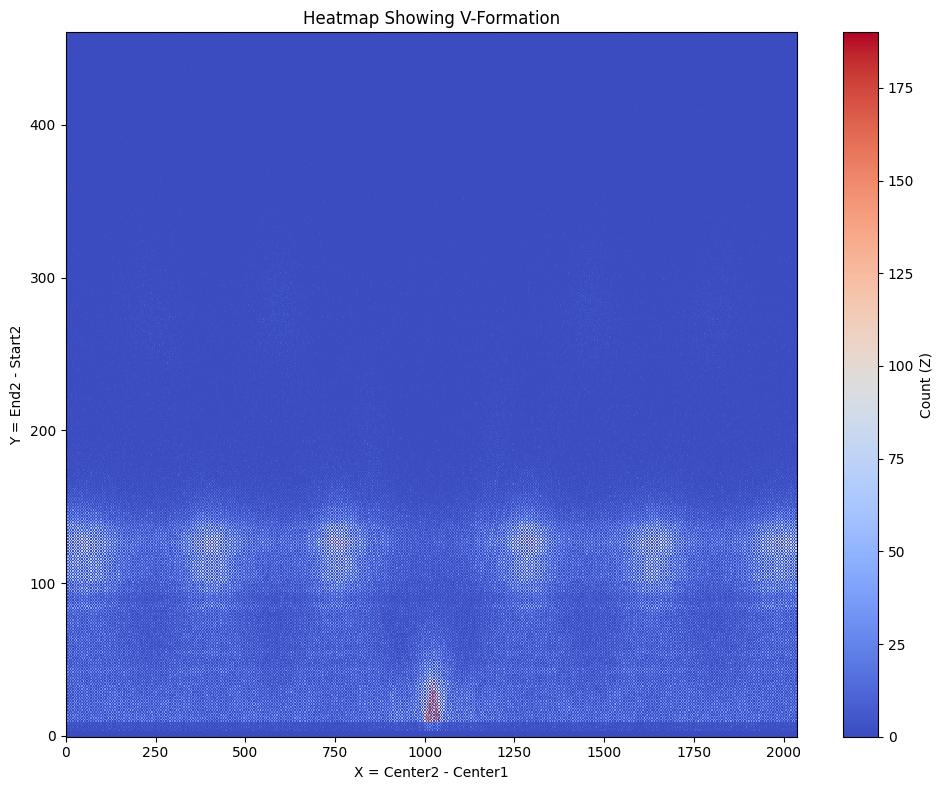

In [9]:
import gzip
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

file_path = 'mapped.bed.gz'
counter = Counter()

# Read and count
with gzip.open(file_path, 'rt') as f:
    for line in f:
        if line.startswith('#') or not line.strip():
            continue
        cols = line.strip().split('\t')
        c1 = (int(cols[2]) + int(cols[3])) / 2
        c2 = (int(cols[8]) + int(cols[9])) / 2
        x = c2 - c1
        y = int(cols[9]) - int(cols[8])
        counter[(x, y)] += 1

# Prepare axes
xs = sorted({xy[0] for xy in counter})
ys = sorted({xy[1] for xy in counter})

# Build heatmap matrix
heatmap = np.zeros((len(ys), len(xs)))
x_to_idx = {x: i for i, x in enumerate(xs)}
y_to_idx = {y: i for i, y in enumerate(ys)}

for (x, y), z in counter.items():
    heatmap[y_to_idx[y], x_to_idx[x]] = z

# Plot with custom background and colormap
fig, ax = plt.subplots(figsize=(10, 8))

# Set axes background color
ax.set_facecolor('#f0f0f0')  # light gray — change as you like

# Render heatmap
cax = ax.imshow(
    heatmap,
    aspect='auto',
    origin='lower',
    cmap='coolwarm',       # try 'viridis', 'magma', 'plasma', etc.
    interpolation='nearest'
)

# Labels and title
ax.set_xlabel('X = Center2 - Center1')
ax.set_ylabel('Y = End2 - Start2')
ax.set_title('Heatmap Showing V-Formation')

# Colorbar
fig.colorbar(cax, ax=ax, label='Count (Z)')

plt.tight_layout()
plt.show()